In [32]:
import os
import hopsworks
import pandas as pd
import joblib
from dotenv import load_dotenv
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
#from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [33]:
# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features_v2", version=1)
df = fg.read()

2026-06-04 22:23:14,900 INFO: Closing external client and cleaning up certificates.
2026-06-04 22:23:14,910 INFO: Connection closed.
2026-06-04 22:23:14,912 INFO: Initializing external client
2026-06-04 22:23:14,913 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-04 22:23:17,604 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.78s) 


In [63]:
df

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-02-01 00:00:00,0.6,0.0,9.3,2.5,0.00,100,5,2435.33,24.59,4.33,1.30,346.10,375.74,5.82,2026-02-01,0,Sialkot
1,2026-02-01 01:00:00,8.6,0.0,9.4,10.8,0.04,97,5,2413.72,23.49,3.61,1.26,353.64,377.72,12.67,2026-02-01,1,Sialkot
2,2026-02-01 02:00:00,3.3,0.0,8.4,9.0,0.00,100,5,2466.80,23.53,2.63,1.66,365.58,389.49,15.17,2026-02-01,2,Sialkot
3,2026-02-01 03:00:00,5.2,0.0,9.4,10.1,0.04,97,5,2593.56,24.47,2.44,2.10,379.25,404.59,15.36,2026-02-01,3,Sialkot
4,2026-02-01 04:00:00,7.4,0.0,12.4,10.8,0.12,92,5,2658.71,22.94,8.73,2.35,382.61,412.41,14.31,2026-02-01,4,Sialkot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2026-05-31 20:00:00,13.8,0.0,28.4,13.7,1.24,63,3,546.83,10.16,90.90,3.98,33.73,44.00,74.03,2026-05-31,20,Sialkot
2685,2026-05-31 21:00:00,12.1,0.0,28.2,9.0,1.05,68,3,512.80,8.73,89.43,3.74,33.55,42.93,76.33,2026-05-31,21,Sialkot
2686,2026-05-31 22:00:00,12.7,0.0,28.0,9.4,1.00,69,3,484.12,7.57,87.81,3.62,33.77,42.59,77.28,2026-05-31,22,Sialkot
2687,2026-05-31 23:00:00,10.6,0.0,27.9,8.6,0.85,73,3,467.00,6.77,87.20,3.60,34.63,43.12,77.39,2026-05-31,23,Sialkot


In [64]:
print("🔪 Preparing data and splitting features...")
df = df.sort_values('datetime').reset_index(drop=True)

# We drop columns that leak the answer, or that math can't understand
columns_to_drop = ['city', 'date', 'datetime', 'aqi', 'pm2_5', 'pm10']

# TODO: Create your 'X' dataframe by dropping the columns above
X = df.drop(columns=columns_to_drop)

# TODO: Create your 'y' series using ONLY the 'pm2_5' column
y = df['pm2_5']

# TODO: Use train_test_split to hide 20% of the data. Set random_state=42 for reproducibility.
# CORRECT FOR TIME SERIES (Chronological Cut)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


🔪 Preparing data and splitting features...


In [65]:
X_train

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,hour
0,0.6,0.0,9.3,2.5,0.00,100,2435.33,24.59,4.33,1.30,5.82,0
1,8.6,0.0,9.4,10.8,0.04,97,2413.72,23.49,3.61,1.26,12.67,1
2,3.3,0.0,8.4,9.0,0.00,100,2466.80,23.53,2.63,1.66,15.17,2
3,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,3
4,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,4
...,...,...,...,...,...,...,...,...,...,...,...,...
2146,12.7,0.1,30.4,26.6,2.90,35,266.05,2.24,174.31,7.04,18.22,10
2147,13.5,0.0,30.3,27.4,2.88,35,293.69,3.68,174.53,8.19,21.35,11
2148,1.8,0.0,32.2,25.9,3.45,28,329.74,5.86,170.90,9.20,24.54,12
2149,1.9,0.0,33.3,6.5,2.37,46,380.02,9.09,161.58,9.68,28.94,13


In [66]:
y_train

0       346.10
1       353.64
2       365.58
3       379.25
4       382.61
         ...  
2146     31.22
2147     33.01
2148     34.11
2149     34.76
2150     36.11
Name: pm2_5, Length: 2151, dtype: float64

In [67]:
X.head(5)

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,hour
0,0.6,0.0,9.3,2.5,0.00,100,2435.33,24.59,4.33,1.30,5.82,0
1,8.6,0.0,9.4,10.8,0.04,97,2413.72,23.49,3.61,1.26,12.67,1
2,3.3,0.0,8.4,9.0,0.00,100,2466.80,23.53,2.63,1.66,15.17,2
3,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,3
4,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,4


In [68]:
# Initialize the competitors
models = {
    "Ridge_Regression": Ridge(),
    "Random_Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

In [69]:
results = {}

# Train and evaluate each model in a loop
for name, model in models.items():
    # TODO: Train the model using the .fit() method on your training data
    model.fit(X_train, y_train)
    
    # TODO: Ask the model to predict PM2.5 for the hidden X_test data
    predictions = model.predict(X_test)
    
    # TODO: Calculate the three required metrics by comparing 'predictions' to 'y_test'
    rmse = root_mean_squared_error(y_test, predictions) 
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model_object": model}
    print(f"✅ {name} trained. R2 Score: {r2:.3f}")

✅ Ridge_Regression trained. R2 Score: 0.078
✅ Random_Forest trained. R2 Score: 0.477
✅ XGBoost trained. R2 Score: 0.428


In [70]:
results['Ridge_Regression']

{'RMSE': 19.763514037000256,
 'MAE': 15.120197424335782,
 'R2': 0.07816344753246907,
 'model_object': Ridge()}

In [71]:
results['Random_Forest']

{'RMSE': 14.886762953666018,
 'MAE': 11.393807249070628,
 'R2': 0.4769705566414155,
 'model_object': RandomForestRegressor(random_state=42)}

In [72]:
results['XGBoost']

{'RMSE': 15.574188422904188,
 'MAE': 11.96820300609206,
 'R2': 0.42755147463714904,
 'model_object': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)}

In [73]:
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_metrics = results[best_model_name]
champion_model = best_metrics['model_object']

print(f"\n🏆 WINNER: {best_model_name} with an R2 of {best_metrics['R2']:.3f}")


🏆 WINNER: Random_Forest with an R2 of 0.477


In [74]:
model = champion_model

In [75]:
import shap
import matplotlib.pyplot as plt

In [76]:
# 1. Initialize JS visualization for the notebook
shap.initjs()

# 2. Create the SHAP Explainer specific to tree-based models (Random Forest)
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for your testing data
# (This might take 10-20 seconds depending on your machine)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated successfully!")

✅ SHAP values calculated successfully!


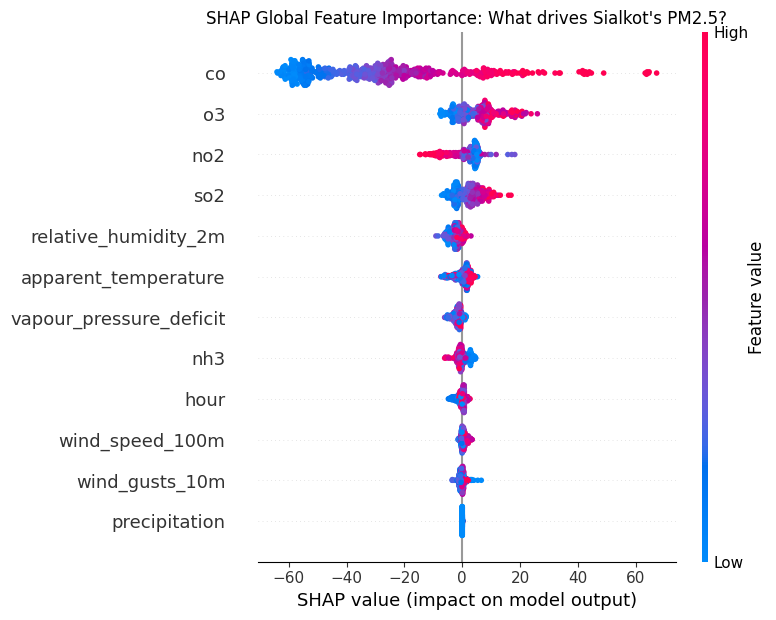

In [77]:
# Plot the global summary (Beeswarm plot)
plt.title("SHAP Global Feature Importance: What drives Sialkot's PM2.5?")
shap.summary_plot(shap_values, X_test)

In [78]:
# Explain the very first prediction in your test set (Hour 0)
# This creates an interactive HTML plot right in your notebook!
shap.force_plot(
    explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    shap_values[0], 
    X_test.iloc[0, :]
)